In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.dates as mdates
from pathlib import Path

# Set up plotting
plt.style.use('default')

In [ ]:
# Load the combined dataset with sensor_idx structure
data_path = Path('../data/2025/processed/lvl1/lvl1_intensive.nc')
ds = xr.open_dataset(data_path)

print(f"Dataset loaded successfully!")
print(f"Dimensions: {dict(ds.sizes)}")
print(f"Variables: {list(ds.data_vars.keys())}")

# Get unique values from sensor metadata
unique_sites = np.unique(ds.site_id.values)
unique_heights = np.unique(ds.height.values)
unique_shielding = np.unique(ds.shielding.values)
unique_sensor_types = np.unique(ds.sensor_type.values)

print(f"Sites: {list(unique_sites)}")
print(f"Heights: {list(unique_heights)}")
print(f"Shielding: {list(unique_shielding)}")
print(f"Sensor types: {list(unique_sensor_types)}")
print(f"Time range: {ds.datetime.values[0]} to {ds.datetime.values[-1]}")
print(f"Total sensors: {len(ds.sensor_idx)}")

print(f"\nDataset structure:")
print(ds)

Dataset loaded successfully!
Dimensions: {'sensor_idx': 11, 'datetime': 119453}
Variables: ['temp_c', 'intensity_lux']
Sites: [np.str_('A02'), np.str_('Divide'), np.str_('Lee1'), np.str_('Lee2'), np.str_('Windward1'), np.str_('Windward2')]
Heights: [np.str_('0.5m'), np.str_('2m')]
Shielding: [np.str_('shielded'), np.str_('unshield'), np.str_('unshielded')]
Sensor types: [np.str_('hobo pendant')]
Time range: 2025-06-17T12:05:00.000000000 to 2025-09-08T10:26:00.000000000
Total sensors: 11

Dataset structure:
<xarray.Dataset> Size: 22MB
Dimensions:            (sensor_idx: 11, datetime: 119453)
Coordinates:
  * sensor_idx         (sensor_idx) int64 88B 0 1 2 3 4 5 6 7 8 9 10
  * datetime           (datetime) datetime64[ns] 956kB 2025-06-17T12:05:00 .....
    sensor_id          (sensor_idx) <U8 352B ...
    site_id            (sensor_idx) <U9 396B 'Lee2' 'Lee2' ... 'Divide' 'Divide'
    height             (sensor_idx) <U4 176B '2m' '2m' '2m' ... '2m' '2m' '2m'
    shielding          (sensor

In [3]:
intensive_site_ids = ["Lee2", "Lee1", "Divide", "Windward1", "Windward2"]

da_pressure = ds['pressure']
da_pressure = da_pressure.where(da_pressure.site_id.isin(intensive_site_ids), drop=True)

da_pressure

KeyError: "No variable named 'pressure'. Variables on the dataset include ['temp_c', 'intensity_lux', 'sensor_id', 'site_id', 'height', ..., 'elevation', 'latitude', 'longitude', 'sensor_idx', 'datetime']"

<xarray.DataArray 'pressure' (datetime: 16389, site_id: 5)> Size: 656kB
array([[  nan,   nan,   nan,   nan,   nan],
       [  nan,   nan,   nan,   nan,   nan],
       [  nan,   nan,   nan,   nan,   nan],
       ...,
       [  nan,   nan, 94.25,   nan,   nan],
       [  nan,   nan, 94.31,   nan,   nan],
       [  nan,   nan, 94.25,   nan,   nan]], shape=(16389, 5))
Coordinates:
  * site_id            (site_id) <U9 180B 'Windward1' 'Lee1' ... 'Divide'
    height             (site_id) <U4 80B '1m' '1m' '1m' '1m' '1m'
    shielding          (site_id) <U10 200B 'unshielded' ... 'unshielded'
    sensor_type        (site_id) <U4 80B 'pace' 'pace' 'pace' 'pace' 'pace'
    sensor_generation  (site_id) <U11 220B ...
    sensor_id          (site_id) <U28 560B ...
    elevation          (site_id) float64 40B ...
    latitude           (site_id) float64 40B ...
    longitude          (site_id) float64 40B ...
    sensor_idx         (site_id) int64 40B 5 14 23 32 41
  * datetime           (datetime)

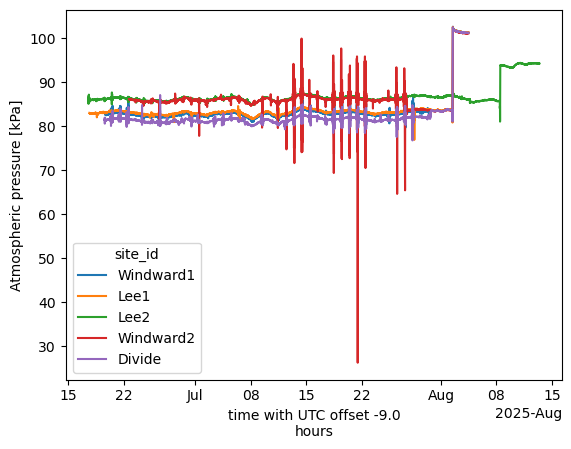

In [ ]:
# Create a boolean mask for sensors at intensive sites
intensive_site_ids = ["Lee2", "Lee1", "Divide", "Windward1", "Windward2"]
site_mask = ds['site_id'].isin(intensive_site_ids)
# Create mask for sensors that actually have pressure data (not all NaN)
has_pressure = ds['pressure'].notnull().any(dim='datetime')

# Combine both conditions
combined_mask = site_mask & has_pressure

# Select only pressure data for those sensors
da_pressure = ds['pressure'].isel(sensor_idx=combined_mask)

# swap coords for ease of use
da_pressure = da_pressure.swap_dims({'sensor_idx': 'site_id'})
print(da_pressure)

da_pressure.plot(hue='site_id')


In [ ]:
print(da_pressure)

<xarray.DataArray 'pressure' (datetime: 16389, side_id: 5)> Size: 656kB
array([[  nan,   nan,   nan,   nan,   nan],
       [  nan,   nan,   nan,   nan,   nan],
       [  nan,   nan,   nan,   nan,   nan],
       ...,
       [  nan,   nan, 94.25,   nan,   nan],
       [  nan,   nan, 94.31,   nan,   nan],
       [  nan,   nan, 94.25,   nan,   nan]], shape=(16389, 5))
Coordinates:
    site_id            (side_id) <U9 180B 'Windward1' 'Lee1' ... 'Divide'
    height             (side_id) <U4 80B '1m' '1m' '1m' '1m' '1m'
    shielding          (side_id) <U10 200B 'unshielded' ... 'unshielded'
    sensor_type        (side_id) <U4 80B 'pace' 'pace' 'pace' 'pace' 'pace'
    sensor_generation  (side_id) <U11 220B ...
    sensor_id          (side_id) <U28 560B ...
    elevation          (side_id) float64 40B ...
    latitude           (side_id) float64 40B ...
    longitude          (side_id) float64 40B ...
    sensor_idx         (side_id) int64 40B 5 14 23 32 41
  * datetime           (datetime)

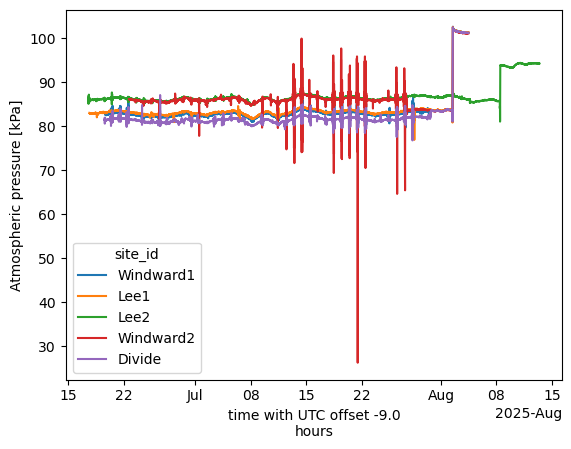